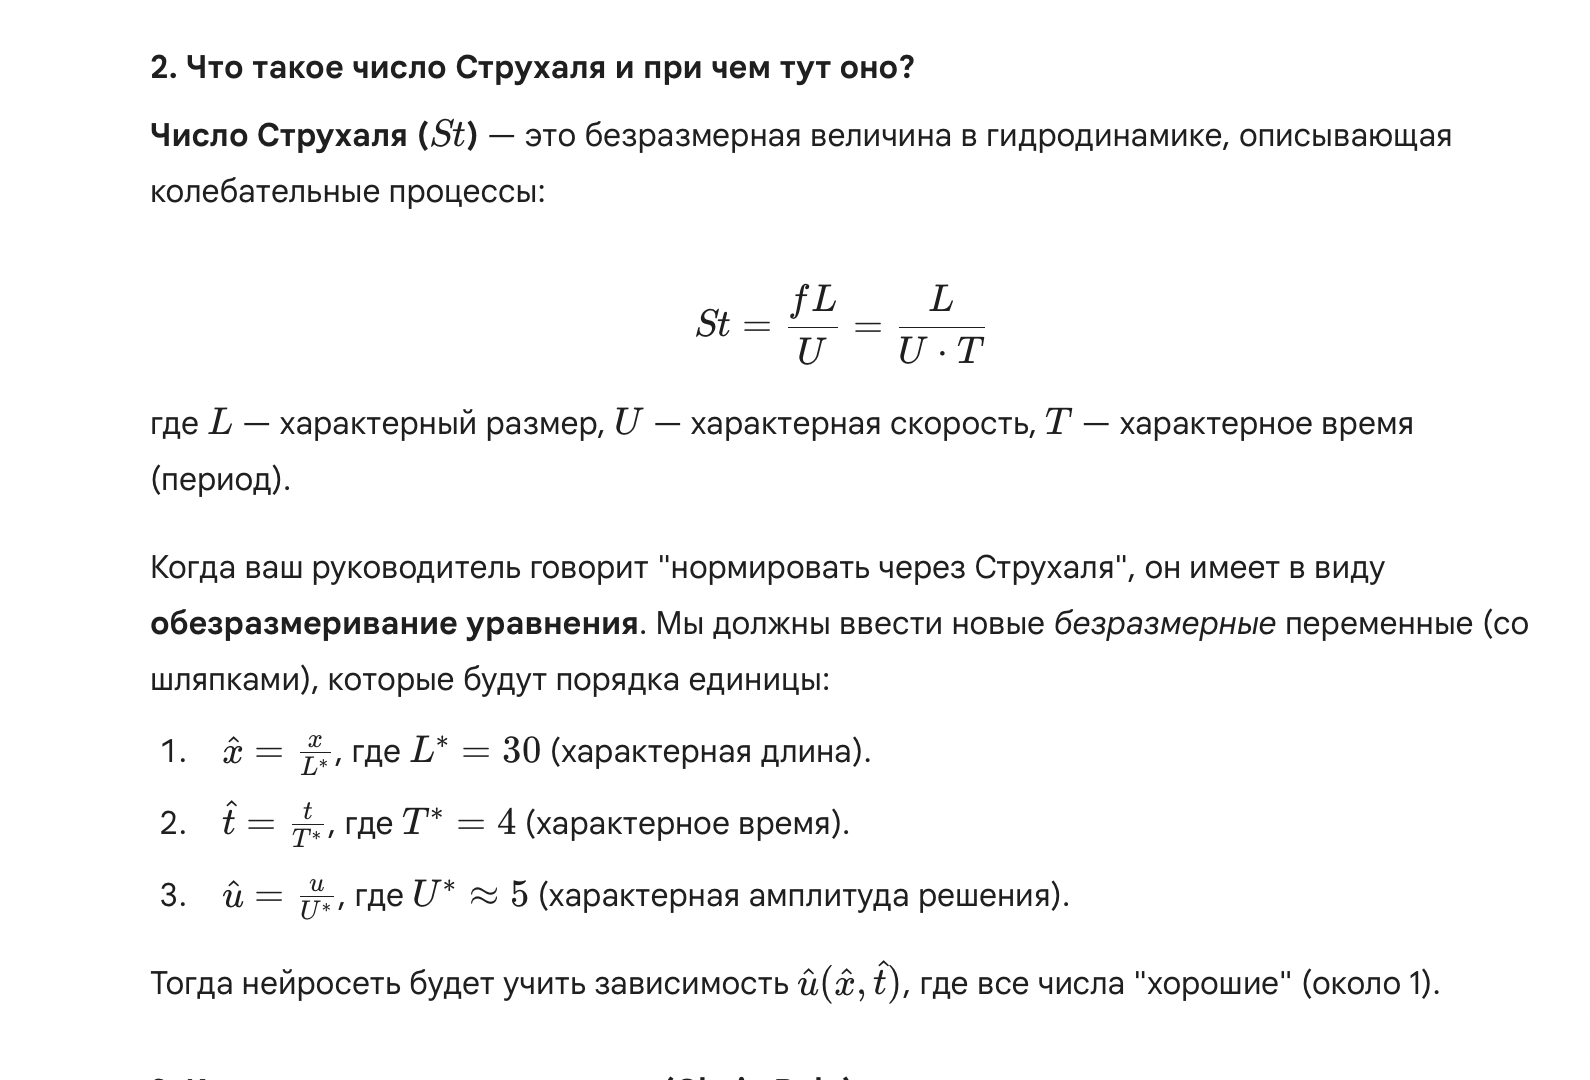

# Потановка задачи 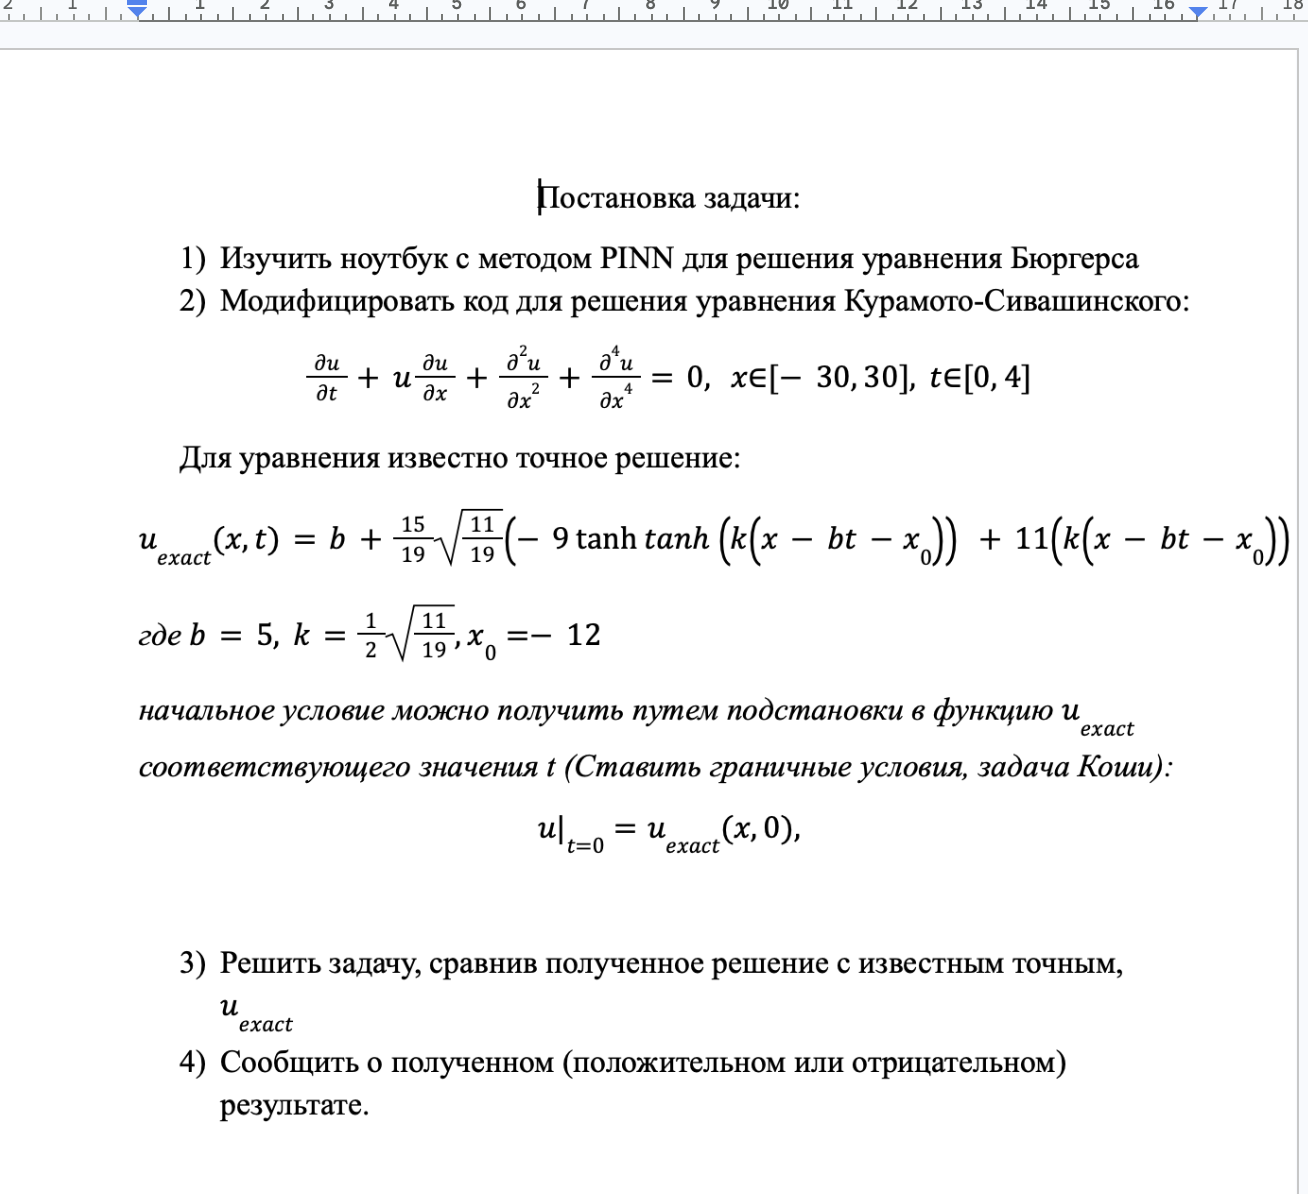
## Уравнение диф
$$ u_t+ u \cdot u_x + u_{xx} + u_{xxxx} = 0 , x \in [30,30], t \in [0,4]$$
## Точное решение 

# Init imports

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import math
from time import time

try:
    from tf_fourier_features import FourierFeatureProjection as ExternalFourierFeatureProjection
    FOURIER_BACKEND = "tf_fourier_features"
except Exception as exc:
    ExternalFourierFeatureProjection = None
    FOURIER_BACKEND = "fallback"
    print("tf_fourier_features is not available.")
    print("Install with: pip install tf-fourier-features")
    print(f"Using fallback Fourier features. Import error: {exc}")


class FallbackFourierFeatureProjection(tf.keras.layers.Layer):
    def __init__(self, gaussian_projection=16, gaussian_scale=1.0, seed=42, trainable=False, **kwargs):
        super().__init__(**kwargs)
        self.gaussian_projection = int(gaussian_projection)
        self.gaussian_scale = float(gaussian_scale)
        self.seed = int(seed)
        self.trainable_projection = bool(trainable)

    def build(self, input_shape):
        self.B = self.add_weight(
            name="B",
            shape=(1, self.gaussian_projection),
            initializer=tf.keras.initializers.RandomNormal(
                mean=0.0,
                stddev=self.gaussian_scale,
                seed=self.seed,
            ),
            trainable=self.trainable_projection,
            dtype=self.dtype,
        )
        super().build(input_shape)

    def call(self, x):
        x = tf.cast(x, self.compute_dtype)
        projection = 2.0 * math.pi * tf.matmul(x, self.B)
        return tf.concat([tf.sin(projection), tf.cos(projection)], axis=-1)


def make_fourier_projection(gaussian_projection, gaussian_scale, seed):
    if ExternalFourierFeatureProjection is not None:
        return ExternalFourierFeatureProjection(
            gaussian_projection=gaussian_projection,
            gaussian_scale=gaussian_scale,
        )
    return FallbackFourierFeatureProjection(
        gaussian_projection=gaussian_projection,
        gaussian_scale=gaussian_scale,
        seed=seed,
    )


# Init Data

In [2]:
DTYPE = "float64"
tf.keras.backend.set_floatx(DTYPE)

SEED = 1234
tf.random.set_seed(SEED)
np.random.seed(SEED)

b = tf.constant(5.0, dtype=DTYPE)
k = tf.constant(0.5 * np.sqrt(11.0 / 19.0), dtype=DTYPE)
c = tf.constant((15.0 / 19.0) * np.sqrt(11.0 / 19.0), dtype=DTYPE)
x0 = tf.constant(-12.0, dtype=DTYPE)
us = tf.constant(10.0, dtype=DTYPE)


def u_exact(t, x):
    t = tf.cast(t, DTYPE)
    x = tf.cast(x, DTYPE)
    z = k * (x - b * t - x0)
    th = tf.tanh(z)
    return (b + c * (-9.0 * th + 11.0 * th**3)) / us


- linspace равновмерный выбор точек на отрезке
- reshape изменение формы массива (в даннном случаи транспонировали вектор)

In [3]:
x = np.linspace(-30.0, 30.0, 200).reshape(-1, 1)


### Постронение графика в точке (0, x) 

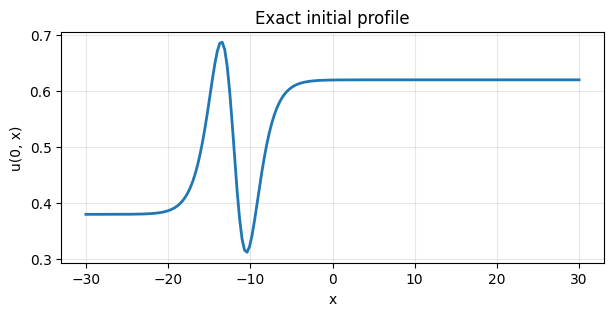

In [4]:
plt.figure(figsize=(7, 3))
plt.plot(x, u_exact(0.0, x), lw=2)
plt.xlabel("x")
plt.ylabel("u(0, x)")
plt.title("Exact initial profile")
plt.grid(True, alpha=0.3)
plt.show()


# Начальное условие 

In [5]:
def fun_u_0(x):
    return u_exact(tf.zeros_like(x, dtype=DTYPE), x)


# Функции описывающие невязки 


In [6]:
def fun_r(t, x, u, u_t, u_x, u_xx, u_xxxx):
    return u_t + us * u * u_x + u_xx + u_xxxx


# Параметры области 

Параметры 
tmin = 0.; tmax = 4.  

xmin = -30.; xmax = 30.  Надо изменить ? получается если нормализируем в этой функции 

In [7]:
N_0 = 300
N_r = 20000
N_b = 2000

tmin, tmax = 0.0, 4.0
xmin, xmax = -30.0, 30.0


# Границы области

In [8]:
lb = tf.constant([tmin, xmin], dtype=DTYPE)
ub = tf.constant([tmax, xmax], dtype=DTYPE)


In [9]:
# Initial condition points: t = 0
t_0 = tf.zeros((N_0, 1), dtype=DTYPE)
x_0 = tf.random.uniform((N_0, 1), lb[1], ub[1], dtype=DTYPE)
X_0 = tf.concat([t_0, x_0], axis=1)
u_0 = fun_u_0(x_0)


### Так понимаю это задание обучающего датасета 
выбираем рандомные точки для обучения (см график)

In [10]:
# Collocation points inside the time-space domain
t_r = tf.random.uniform((N_r, 1), lb[0] + 1e-6, ub[0], dtype=DTYPE)
x_r = tf.random.uniform((N_r, 1), lb[1], ub[1], dtype=DTYPE)
X_r = tf.concat([t_r, x_r], axis=1)


Граничные условия 


In [11]:
# Boundary points: x = xmin and x = xmax at identical time t_b
t_b = tf.random.uniform((N_b, 1), lb[0], ub[0], dtype=DTYPE)

x_lb = tf.ones((N_b, 1), dtype=DTYPE) * lb[1]
x_ub = tf.ones((N_b, 1), dtype=DTYPE) * ub[1]

X_lb = tf.concat([t_b, x_lb], axis=1)
X_ub = tf.concat([t_b, x_ub], axis=1)

tf.debugging.assert_near(X_lb[:, 0:1], X_ub[:, 0:1])


In [12]:
# Boundary sample sanity check
print("X_lb shape:", X_lb.shape, "X_ub shape:", X_ub.shape)
print("Same time samples on left/right:", bool(tf.reduce_all(tf.equal(X_lb[:, 0:1], X_ub[:, 0:1]))))
print("Unique x on left boundary:", np.unique(X_lb[:, 1].numpy())[:5])
print("Unique x on right boundary:", np.unique(X_ub[:, 1].numpy())[:5])


X_lb shape: (2000, 2) X_ub shape: (2000, 2)
Same time samples on left/right: True
Unique x on left boundary: [-30.]
Unique x on right boundary: [30.]


In [13]:
X_data = [X_0]
u_data = [u_0]


# График точного решения 

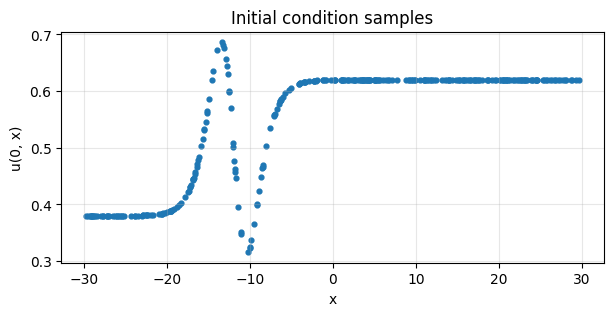

In [14]:
plt.figure(figsize=(7, 3))
plt.scatter(X_0[:, 1:2], u_0, s=12)
plt.xlabel("x")
plt.ylabel("u(0, x)")
plt.title("Initial condition samples")
plt.grid(True, alpha=0.3)
plt.show()


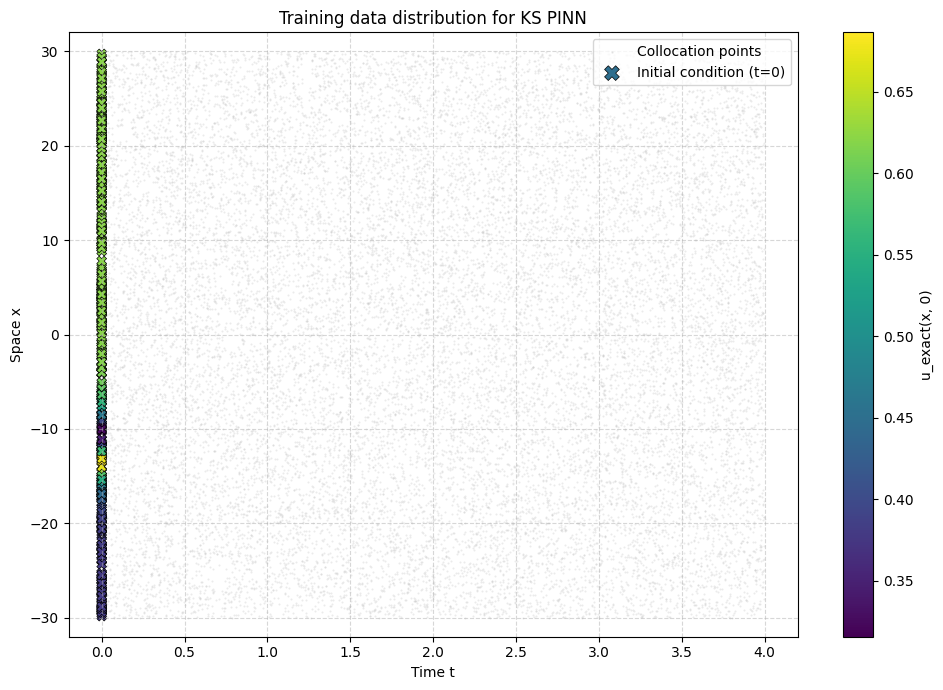

In [15]:
fig = plt.figure(figsize=(10, 7))

plt.scatter(t_r, x_r, c="silver", marker=".", s=1, alpha=0.3, label="Collocation points")
sc = plt.scatter(
    t_0,
    x_0,
    c=u_0,
    marker="X",
    s=50,
    cmap="viridis",
    edgecolors="black",
    linewidths=0.5,
    vmin=float(tf.reduce_min(u_0)),
    vmax=float(tf.reduce_max(u_0)),
    label="Initial condition (t=0)",
)

plt.xlabel("Time t")
plt.ylabel("Space x")
plt.xlim(tmin - 0.2, tmax + 0.2)
plt.ylim(xmin - 2.0, xmax + 2.0)
plt.legend(loc="upper right", markerscale=1.5)
plt.title("Training data distribution for KS PINN")
cbar = plt.colorbar(sc)
cbar.set_label("u_exact(x, 0)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


In [16]:
# Scalar weights for loss terms
lambda_r = tf.constant(1.0, dtype=DTYPE)
lambda_b = tf.constant(1.0, dtype=DTYPE)
lambda_0 = tf.constant(1.0, dtype=DTYPE)

# Pointwise weights kept explicit in formulas
w_r = tf.ones((N_r, 1), dtype=DTYPE)
w_0 = tf.ones((N_0, 1), dtype=DTYPE)


Хочет начальные признаки обработать начальные условия Фурие чтобы добавить новых признаков ??? 
Которые мы скормим модели 

если есть точка tx может чет потом погуглить

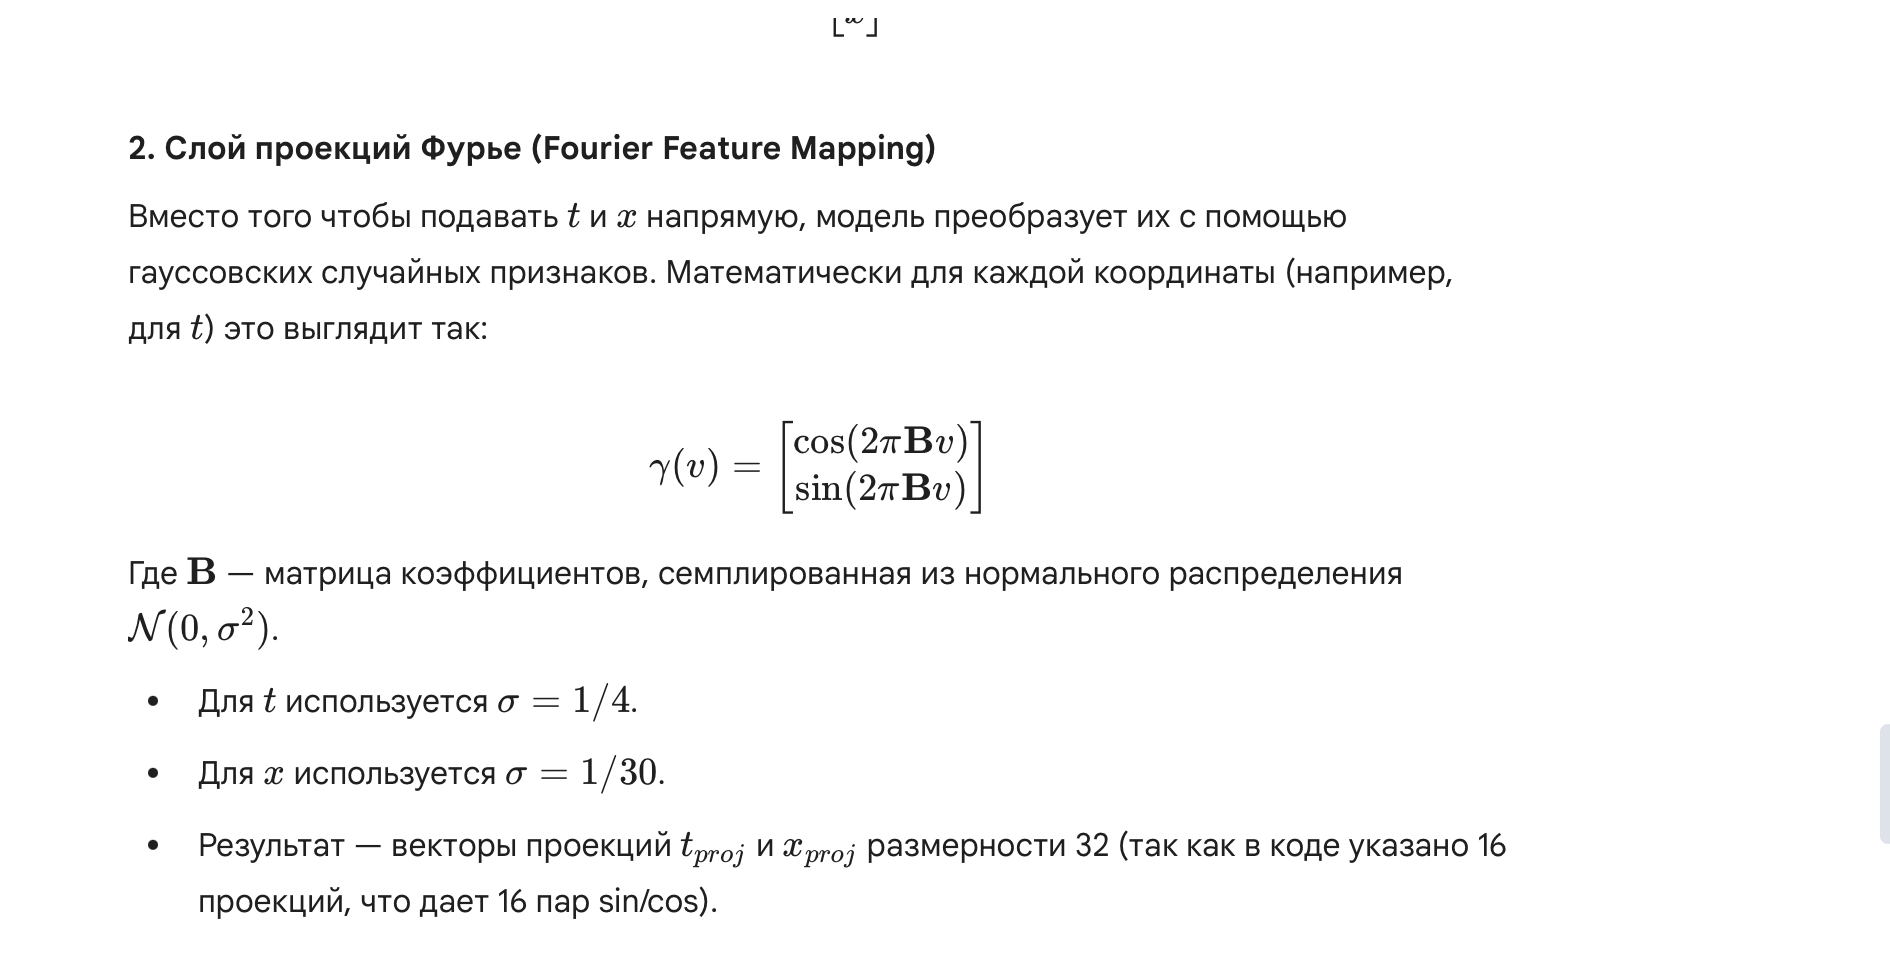

In [17]:
class MyModel(tf.keras.Model):
    def __init__(self, num_hidden_layers=4, hidden_dim=64, num_fourier=16, act="linear"):
        super().__init__()
        self.t_proj = make_fourier_projection(
            gaussian_projection=num_fourier,
            gaussian_scale=1.0 / 4.0,
            seed=101,
        )
        self.x_proj = make_fourier_projection(
            gaussian_projection=num_fourier,
            gaussian_scale=1.0 / 30.0,
            seed=202,
        )

        self.hidden_layers = [
            tf.keras.layers.Dense(hidden_dim, activation="tanh")
            for _ in range(num_hidden_layers)
        ]
        self.output_layer = tf.keras.layers.Dense(1, activation=act)

    def call(self, inputs):
        inputs = tf.cast(inputs, DTYPE)
        t = inputs[:, 0:1]
        x = inputs[:, 1:2]

        t_features = tf.cast(self.t_proj(t), DTYPE)
        x_features = tf.cast(self.x_proj(x), DTYPE)
        features = tf.concat([t_features, x_features], axis=1)

        h = features
        for layer in self.hidden_layers:
            h = layer(h)

        return self.output_layer(h)


Невязка

In [18]:
def get_r(model, X_r):
    t = X_r[:, 0:1]
    x = X_r[:, 1:2]

    with tf.GradientTape(persistent=True) as tape4:
        tape4.watch([t, x])
        with tf.GradientTape(persistent=True) as tape3:
            tape3.watch([t, x])
            with tf.GradientTape(persistent=True) as tape2:
                tape2.watch([t, x])
                with tf.GradientTape(persistent=True) as tape1:
                    tape1.watch([t, x])
                    u = model(tf.concat([t, x], axis=1))
                u_x = tape1.gradient(u, x)
                u_t = tape1.gradient(u, t)
            u_xx = tape2.gradient(u_x, x)
        u_xxx = tape3.gradient(u_xx, x)
    u_xxxx = tape4.gradient(u_xxx, x)

    del tape1, tape2, tape3, tape4

    return fun_r(t, x, u, u_t, u_x, u_xx, u_xxxx)


In [19]:
def get_boundary_residuals_from_exact(model, X_lb, X_ub):
    t_lb, x_lb = X_lb[:, 0:1], X_lb[:, 1:2]
    t_ub, x_ub = X_ub[:, 0:1], X_ub[:, 1:2]

    with tf.GradientTape(persistent=True) as tape2_pred:
        tape2_pred.watch([x_lb, x_ub])
        with tf.GradientTape(persistent=True) as tape1_pred:
            tape1_pred.watch([x_lb, x_ub])
            u_lb = model(tf.concat([t_lb, x_lb], axis=1))
            u_ub = model(tf.concat([t_ub, x_ub], axis=1))
        u_x_lb = tape1_pred.gradient(u_lb, x_lb)
        u_x_ub = tape1_pred.gradient(u_ub, x_ub)
    u_xx_lb = tape2_pred.gradient(u_x_lb, x_lb)
    u_xx_ub = tape2_pred.gradient(u_x_ub, x_ub)

    with tf.GradientTape(persistent=True) as tape2_exact:
        tape2_exact.watch([x_lb, x_ub])
        with tf.GradientTape(persistent=True) as tape1_exact:
            tape1_exact.watch([x_lb, x_ub])
            u_exact_lb = u_exact(t_lb, x_lb)
            u_exact_ub = u_exact(t_ub, x_ub)
        u_exact_x_lb = tape1_exact.gradient(u_exact_lb, x_lb)
        u_exact_x_ub = tape1_exact.gradient(u_exact_ub, x_ub)
    u_exact_xx_lb = tape2_exact.gradient(u_exact_x_lb, x_lb)
    u_exact_xx_ub = tape2_exact.gradient(u_exact_x_ub, x_ub)

    del tape1_pred, tape2_pred, tape1_exact, tape2_exact

    r_u = tf.concat([u_lb - u_exact_lb, u_ub - u_exact_ub], axis=0)
    r_ux = tf.concat([u_x_lb - u_exact_x_lb, u_x_ub - u_exact_x_ub], axis=0)
    r_uxx = tf.concat([u_xx_lb - u_exact_xx_lb, u_xx_ub - u_exact_xx_ub], axis=0)

    return r_u, r_ux, r_uxx


In [20]:
def compute_loss_components(
    model,
    X_r,
    X_data,
    u_data,
    X_lb,
    X_ub,
    w_r,
    w_0,
    lambda_r,
    lambda_b,
    lambda_0,
):
    r = get_r(model, X_r)
    phi_r = tf.reduce_mean(tf.square(w_r * r))

    r_u_b, r_ux_b, r_uxx_b = get_boundary_residuals_from_exact(model, X_lb, X_ub)
    phi_b_u = tf.reduce_mean(tf.square(r_u_b))
    phi_b_ux = tf.reduce_mean(tf.square(r_ux_b))
    phi_b_uxx = tf.reduce_mean(tf.square(r_uxx_b))
    phi_b = phi_b_u + phi_b_ux + phi_b_uxx

    phi_0 = tf.constant(0.0, dtype=DTYPE)
    for i in range(len(X_data)):
        u_pred = model(X_data[i])
        phi_0 += tf.reduce_mean(tf.square(w_0 * (u_data[i] - u_pred)))

    total_loss = lambda_r * phi_r + lambda_b * phi_b + lambda_0 * phi_0
    return total_loss, phi_r, phi_b, phi_0, phi_b_u, phi_b_ux, phi_b_uxx


# Градиент 
Строится для того чтобы найти Минимум ошибки (функции потель )

In [21]:
def get_grad(
    model,
    X_r,
    X_data,
    u_data,
    X_lb,
    X_ub,
    w_r,
    w_0,
    lambda_r,
    lambda_b,
    lambda_0,
):
    with tf.GradientTape() as tape:
        total_loss, phi_r, phi_b, phi_0, phi_b_u, phi_b_ux, phi_b_uxx = compute_loss_components(
            model,
            X_r,
            X_data,
            u_data,
            X_lb,
            X_ub,
            w_r,
            w_0,
            lambda_r,
            lambda_b,
            lambda_0,
        )

    grad_theta = tape.gradient(total_loss, model.trainable_variables)
    return total_loss, phi_r, phi_b, phi_0, phi_b_u, phi_b_ux, phi_b_uxx, grad_theta


In [22]:
model = MyModel()

lr = 2e-4
optim = tf.keras.optimizers.Adam(learning_rate=lr)


Для всего графика построили пирближение 

In [23]:
x_plot = np.linspace(xmin, xmax, 400).reshape(-1, 1)
y_ref_0 = u_exact(np.full_like(x_plot, tmin), x_plot).numpy().reshape(-1)
y_ref_t = u_exact(np.full_like(x_plot, tmax), x_plot).numpy().reshape(-1)
y_min = min(y_ref_0.min(), y_ref_t.min())
y_max = max(y_ref_0.max(), y_ref_t.max())
y_pad = 0.10 * (y_max - y_min + 1e-12)
PLOT_YLIM = (y_min - y_pad, y_max + y_pad)


def plot(c=0.0, ax=None):
    t = np.full_like(x_plot, c)
    xt = np.hstack([t, x_plot])
    xt_tf = tf.convert_to_tensor(xt, dtype=DTYPE)

    u_pred = model(xt_tf).numpy().reshape(-1)
    u_ref = u_exact(t, x_plot).numpy().reshape(-1)

    created_fig = False
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 3))
        created_fig = True

    ax.plot(x_plot, u_pred, lw=2, label="PINN prediction")
    ax.plot(x_plot, u_ref, "--", lw=2, label="Exact solution")
    ax.set_xlabel("x")
    ax.set_ylabel("u(t, x)")
    ax.set_title(f"Solution slice at t={c:.2f}")
    ax.set_ylim(*PLOT_YLIM)
    ax.grid(True, alpha=0.3)
    ax.legend()

    if created_fig:
        plt.tight_layout()
        plt.show()


def plot_slices(times=(0.0, 4.0)):
    fig, axes = plt.subplots(1, len(times), figsize=(6 * len(times), 3.5), sharey=True)
    if len(times) == 1:
        axes = [axes]
    for ax, current_t in zip(axes, times):
        plot(current_t, ax=ax)
    plt.tight_layout()
    plt.show()


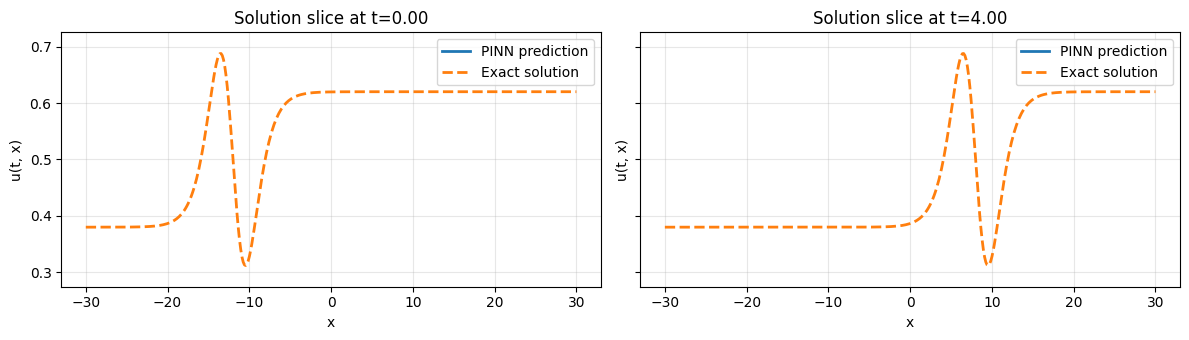

In [24]:
plot_slices((0.0, 4.0))


It 00000: total=1.86959966e+00, phi_r=6.81406083e-02, phi_b=8.88082645e-01, phi_0=9.13376407e-01


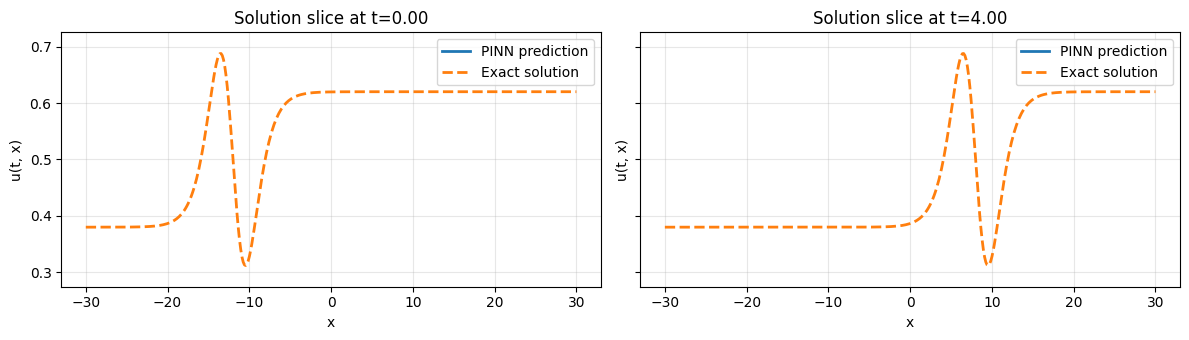

It 00050: total=3.57830132e-02, phi_r=2.22948703e-02, phi_b=7.64065424e-03, phi_0=5.84748864e-03
It 00100: total=1.10772178e-02, phi_r=7.04883450e-03, phi_b=1.22005259e-03, phi_0=2.80833066e-03
It 00150: total=6.10038782e-03, phi_r=3.40637493e-03, phi_b=6.19837722e-04, phi_0=2.07417517e-03
It 00200: total=4.26781097e-03, phi_r=2.18269591e-03, phi_b=3.62578094e-04, phi_0=1.72253696e-03
It 00250: total=3.38262881e-03, phi_r=1.62427285e-03, phi_b=2.39049311e-04, phi_0=1.51930664e-03
It 00300: total=2.88150566e-03, phi_r=1.31955576e-03, phi_b=1.71787509e-04, phi_0=1.39016239e-03
It 00350: total=2.55762240e-03, phi_r=1.12586905e-03, phi_b=1.29815099e-04, phi_0=1.30193824e-03
It 00400: total=2.32613490e-03, phi_r=9.87658865e-04, phi_b=1.01076940e-04, phi_0=1.23739910e-03
It 00450: total=2.15016376e-03, phi_r=8.82889214e-04, phi_b=8.04907948e-05, phi_0=1.18678376e-03
It 00500: total=2.01133971e-03, phi_r=8.01232184e-04, phi_b=6.54413116e-05, phi_0=1.14466621e-03
It 00550: total=1.89890191e-03

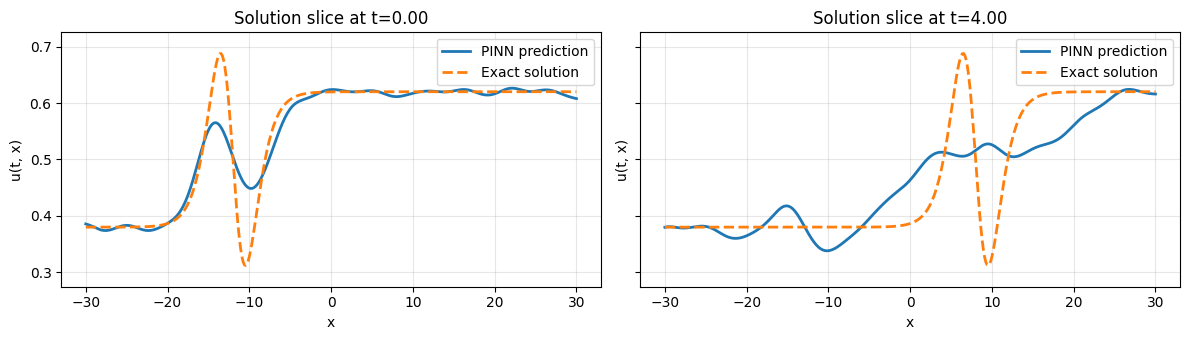

It 01050: total=1.34385162e-03, phi_r=4.67439473e-04, phi_b=1.77668281e-05, phi_0=8.58645317e-04
It 01100: total=1.31124826e-03, phi_r=4.55959786e-04, phi_b=1.66324464e-05, phi_0=8.38656032e-04
It 01150: total=1.28042320e-03, phi_r=4.45669894e-04, phi_b=1.56451465e-05, phi_0=8.19108158e-04
It 01200: total=1.25113258e-03, phi_r=4.36395058e-04, phi_b=1.47758773e-05, phi_0=7.99961648e-04
It 01250: total=1.22317577e-03, phi_r=4.27989797e-04, phi_b=1.40012329e-05, phi_0=7.81184743e-04
It 01300: total=1.19638759e-03, phi_r=4.20333100e-04, phi_b=1.33025324e-05, phi_0=7.62751959e-04
It 01350: total=1.17063225e-03, phi_r=4.13324484e-04, phi_b=1.26650641e-05, phi_0=7.44642698e-04
It 01400: total=1.14579831e-03, phi_r=4.06880600e-04, phi_b=1.20774314e-05, phi_0=7.26840275e-04
It 01450: total=1.12179447e-03, phi_r=4.00932270e-04, phi_b=1.15309730e-05, phi_0=7.09331231e-04
It 01500: total=1.09854599e-03, phi_r=3.95421900e-04, phi_b=1.10192508e-05, phi_0=6.92104835e-04
It 01550: total=1.07599156e-03

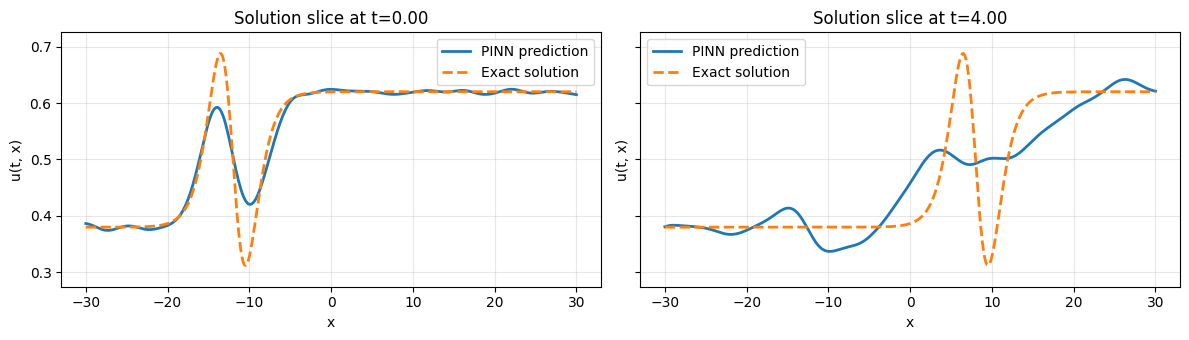

It 02050: total=8.80788551e-04, phi_r=3.53787123e-04, phi_b=6.99616424e-06, phi_0=5.20005264e-04
It 02100: total=8.63837392e-04, phi_r=3.51152617e-04, phi_b=6.75681518e-06, phi_0=5.05927960e-04
It 02150: total=8.47299961e-04, phi_r=3.48644817e-04, phi_b=6.53645661e-06, phi_0=4.92118687e-04
It 02200: total=8.31166619e-04, phi_r=3.46252899e-04, phi_b=6.33424393e-06, phi_0=4.78579477e-04
It 02250: total=8.15428016e-04, phi_r=3.43966705e-04, phi_b=6.14919125e-06, phi_0=4.65312120e-04
It 02300: total=8.00074848e-04, phi_r=3.41776607e-04, phi_b=5.98019086e-06, phi_0=4.52318050e-04
It 02350: total=7.85097645e-04, phi_r=3.39673363e-04, phi_b=5.82603873e-06, phi_0=4.39598243e-04
It 02400: total=7.70486584e-04, phi_r=3.37647996e-04, phi_b=5.68546320e-06, phi_0=4.27153124e-04
It 02450: total=7.56231339e-04, phi_r=3.35691688e-04, phi_b=5.55715485e-06, phi_0=4.14982496e-04
It 02500: total=7.42320975e-04, phi_r=3.33795693e-04, phi_b=5.43979543e-06, phi_0=4.03085487e-04
It 02550: total=7.28743890e-04

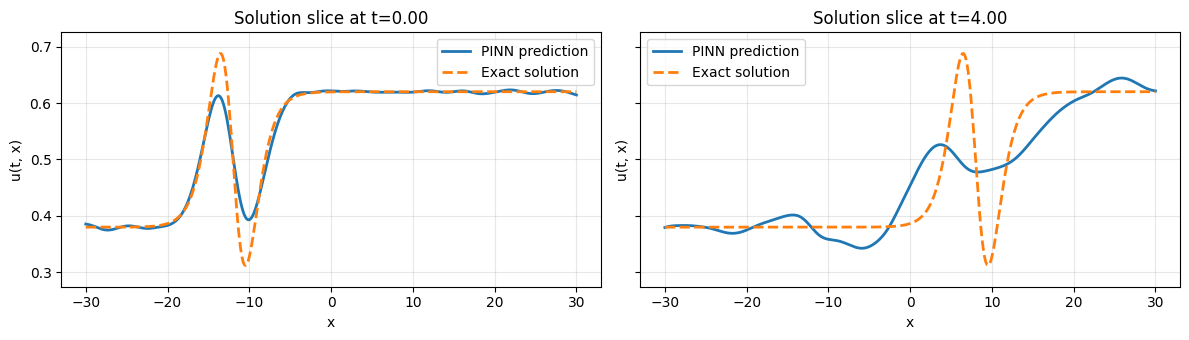

It 03050: total=6.08398471e-04, phi_r=3.14498071e-04, phi_b=4.54560333e-06, phi_0=2.89354797e-04
It 03100: total=5.97609316e-04, phi_r=3.12690870e-04, phi_b=4.47817366e-06, phi_0=2.80440273e-04
It 03150: total=5.86997362e-04, phi_r=3.10850703e-04, phi_b=4.41070557e-06, phi_0=2.71735953e-04
It 03200: total=5.76552763e-04, phi_r=3.08974534e-04, phi_b=4.34294710e-06, phi_0=2.63235283e-04
It 03250: total=5.66266697e-04, phi_r=3.07060079e-04, phi_b=4.27471453e-06, phi_0=2.54931903e-04
It 03300: total=5.56131411e-04, phi_r=3.05105783e-04, phi_b=4.20588571e-06, phi_0=2.46819743e-04
It 03350: total=5.46140276e-04, phi_r=3.03110778e-04, phi_b=4.13639312e-06, phi_0=2.38893105e-04
It 03400: total=5.36287821e-04, phi_r=3.01074851e-04, phi_b=4.06621671e-06, phi_0=2.31146754e-04
It 03450: total=5.26569764e-04, phi_r=2.98998395e-04, phi_b=3.99537686e-06, phi_0=2.23575992e-04
It 03500: total=5.16983028e-04, phi_r=2.96882372e-04, phi_b=3.92392756e-06, phi_0=2.16176728e-04
It 03550: total=5.07525740e-04

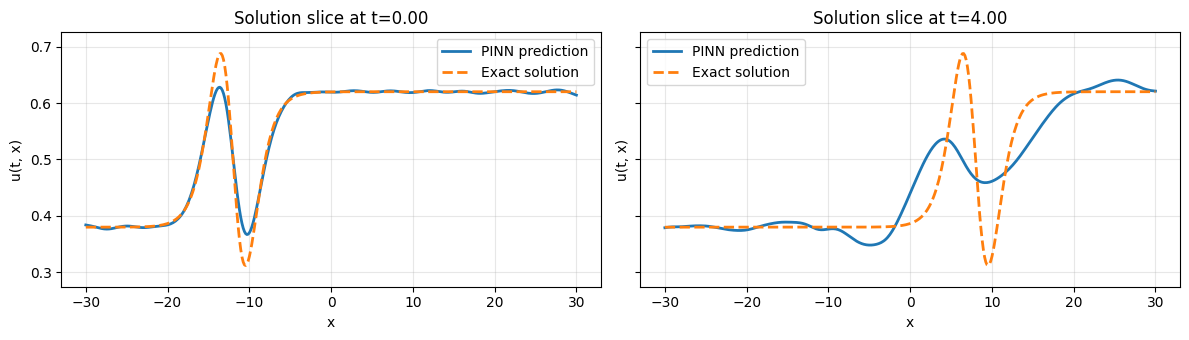

It 04050: total=4.20381914e-04, phi_r=2.71640783e-04, phi_b=3.12884385e-06, phi_0=1.45612287e-04
It 04100: total=4.12484376e-04, phi_r=2.69237321e-04, phi_b=3.05856523e-06, phi_0=1.40188490e-04
It 04150: total=4.04748973e-04, phi_r=2.66825040e-04, phi_b=2.98890825e-06, phi_0=1.34935025e-04
It 04200: total=3.97176935e-04, phi_r=2.64404593e-04, phi_b=2.91987612e-06, phi_0=1.29852466e-04
It 04250: total=3.89768173e-04, phi_r=2.61975966e-04, phi_b=2.85145814e-06, phi_0=1.24940749e-04
It 04300: total=3.82521116e-04, phi_r=2.59538424e-04, phi_b=2.78363513e-06, phi_0=1.20199057e-04
It 04350: total=3.75432602e-04, phi_r=2.57090477e-04, phi_b=2.71638583e-06, phi_0=1.15625739e-04
It 04400: total=3.68497818e-04, phi_r=2.54629865e-04, phi_b=2.64969393e-06, phi_0=1.11218259e-04
It 04450: total=3.61710309e-04, phi_r=2.52153571e-04, phi_b=2.58355494e-06, phi_0=1.06973183e-04
It 04500: total=3.55062044e-04, phi_r=2.49657864e-04, phi_b=2.51798234e-06, phi_0=1.02886197e-04
It 04550: total=3.48543537e-04

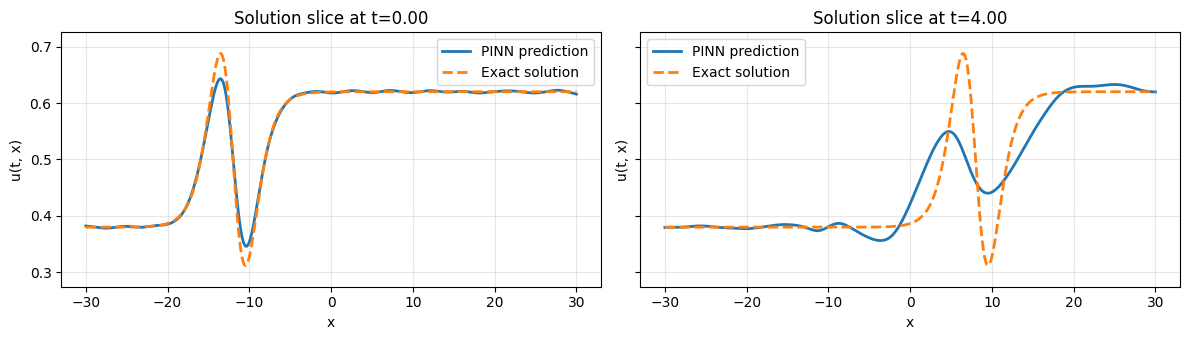

It 05050: total=2.87806058e-04, phi_r=2.19445285e-04, phi_b=1.86115839e-06, phi_0=6.64996150e-05
It 05100: total=2.81902390e-04, phi_r=2.16314852e-04, phi_b=1.81116470e-06, phi_0=6.37763730e-05
It 05150: total=2.75990029e-04, phi_r=2.13106553e-04, phi_b=1.76341156e-06, phi_0=6.11200645e-05
It 05200: total=2.70065042e-04, phi_r=2.09821508e-04, phi_b=1.71796142e-06, phi_0=5.85255719e-05
It 05250: total=2.64126631e-04, phi_r=2.06463034e-04, phi_b=1.67482816e-06, phi_0=5.59887691e-05
It 05300: total=2.58177694e-04, phi_r=2.03037050e-04, phi_b=1.63396761e-06, phi_0=5.35066758e-05
It 05350: total=2.52225338e-04, phi_r=1.99552458e-04, phi_b=1.59526869e-06, phi_0=5.10776109e-05
It 05400: total=2.46281289e-04, phi_r=1.96021406e-04, phi_b=1.55854639e-06, phi_0=4.87013367e-05
It 05450: total=2.88534674e-04, phi_r=2.29042376e-04, phi_b=1.42521808e-05, phi_0=4.52401168e-05
It 05500: total=2.35371193e-04, phi_r=1.90144479e-04, phi_b=1.63177323e-06, phi_0=4.35949402e-05
It 05550: total=2.29493348e-04

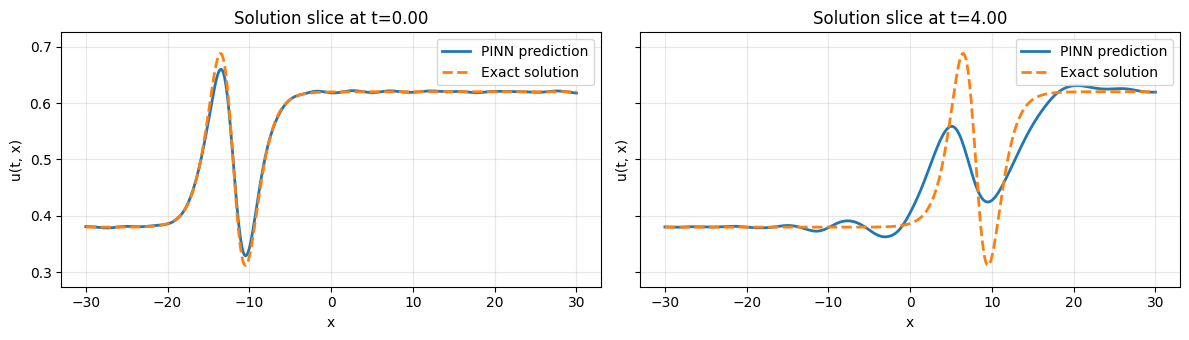

It 06050: total=1.83292101e-04, phi_r=1.56099556e-04, phi_b=1.13319121e-06, phi_0=2.60593540e-05
It 06100: total=1.79598008e-04, phi_r=1.53574237e-04, phi_b=1.10255641e-06, phi_0=2.49212143e-05
It 06150: total=1.76002274e-04, phi_r=1.51078085e-04, phi_b=1.07219439e-06, phi_0=2.38519952e-05
It 06200: total=1.84867197e-04, phi_r=1.58134554e-04, phi_b=3.44423268e-06, phi_0=2.32884099e-05
It 06250: total=1.69547751e-04, phi_r=1.46587026e-04, phi_b=1.02357416e-06, phi_0=2.19371510e-05
It 06300: total=1.66343629e-04, phi_r=1.44126849e-04, phi_b=9.85078748e-07, phi_0=2.12317014e-05
It 06350: total=1.63248342e-04, phi_r=1.41868868e-04, phi_b=9.60362566e-07, phi_0=2.04191120e-05
It 06400: total=1.84449055e-04, phi_r=1.55337821e-04, phi_b=6.82724411e-06, phi_0=2.22839897e-05
It 06450: total=1.57474250e-04, phi_r=1.37276412e-04, phi_b=9.21867954e-07, phi_0=1.92759708e-05
It 06500: total=1.54514613e-04, phi_r=1.35326348e-04, phi_b=8.88805184e-07, phi_0=1.82994592e-05
It 06550: total=1.51626876e-04

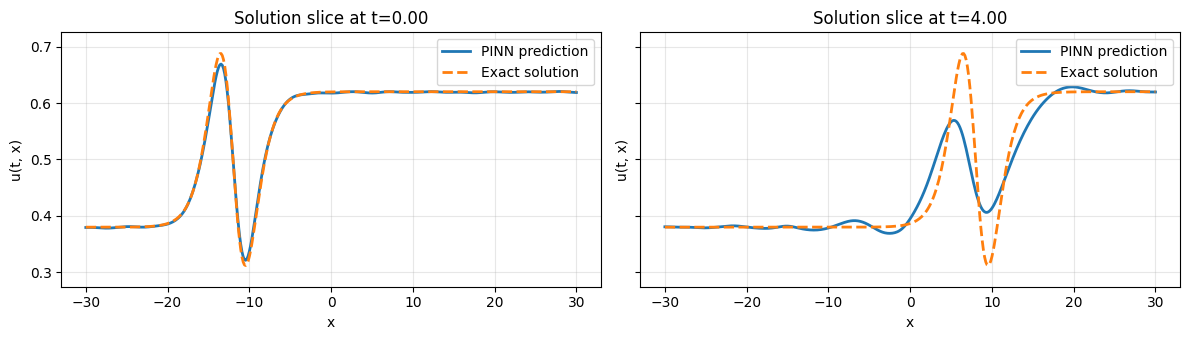

It 07050: total=1.25198484e-04, phi_r=1.10707439e-04, phi_b=9.05487627e-07, phi_0=1.35855567e-05
It 07100: total=1.21303317e-04, phi_r=1.08633428e-04, phi_b=7.08902171e-07, phi_0=1.19609870e-05
It 07150: total=1.18410049e-04, phi_r=1.06322493e-04, phi_b=7.00122529e-07, phi_0=1.13874333e-05
It 07200: total=1.20519991e-04, phi_r=1.07118386e-04, phi_b=1.53759074e-06, phi_0=1.18640139e-05
It 07250: total=1.12720767e-04, phi_r=1.01471033e-04, phi_b=6.81751643e-07, phi_0=1.05679827e-05
It 07300: total=1.30133284e-04, phi_r=1.04051088e-04, phi_b=4.77473877e-06, phi_0=2.13074568e-05
It 07350: total=1.06923407e-04, phi_r=9.65121188e-05, phi_b=6.64054555e-07, phi_0=9.74723331e-06
It 07400: total=1.03956315e-04, phi_r=9.40702106e-05, phi_b=6.55748563e-07, phi_0=9.23035546e-06
It 07450: total=1.01232959e-04, phi_r=9.12199823e-05, phi_b=7.03595500e-07, phi_0=9.30938140e-06
It 07500: total=9.84327237e-05, phi_r=8.95181759e-05, phi_b=7.30591061e-07, phi_0=8.18395673e-06
It 07550: total=9.71914090e-05

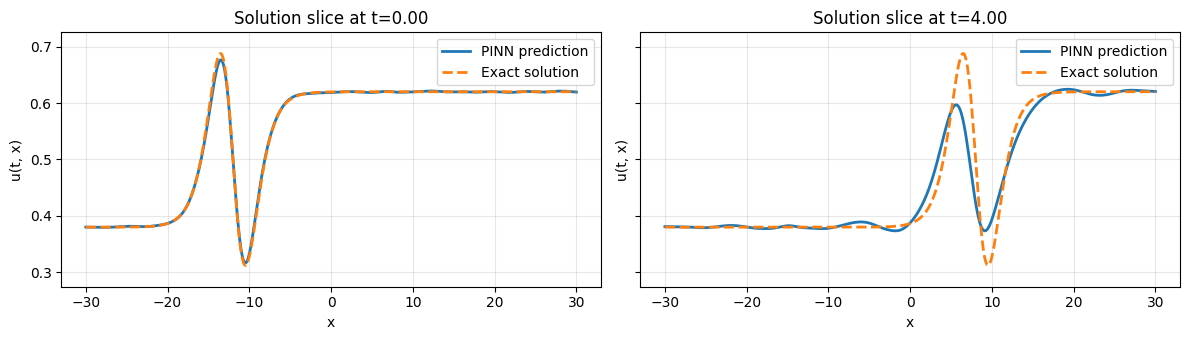

It 08050: total=6.80816974e-05, phi_r=6.26505968e-05, phi_b=5.70162054e-07, phi_0=4.86093854e-06
It 08100: total=6.56139479e-05, phi_r=6.05183304e-05, phi_b=5.60065622e-07, phi_0=4.53555184e-06
It 08150: total=6.42284491e-05, phi_r=5.86293990e-05, phi_b=8.20674499e-07, phi_0=4.77837558e-06
It 08200: total=6.13145249e-05, phi_r=5.62145280e-05, phi_b=6.47068702e-07, phi_0=4.45292820e-06
It 08250: total=5.94273914e-05, phi_r=5.51419280e-05, phi_b=7.13831130e-07, phi_0=3.57163228e-06
It 08300: total=5.65889346e-05, phi_r=5.24461376e-05, phi_b=5.39774874e-07, phi_0=3.60302207e-06
It 08350: total=5.44053524e-05, phi_r=5.04659593e-05, phi_b=5.32904969e-07, phi_0=3.40648815e-06
It 08400: total=1.33421380e-04, phi_r=7.77306817e-05, phi_b=1.86703732e-05, phi_0=3.70203254e-05
It 08450: total=5.04199100e-05, phi_r=4.68842502e-05, phi_b=5.29503305e-07, phi_0=3.00615645e-06
It 08500: total=4.84278342e-05, phi_r=4.50329253e-05, phi_b=5.18359382e-07, phi_0=2.87654958e-06
It 08550: total=4.95875954e-05

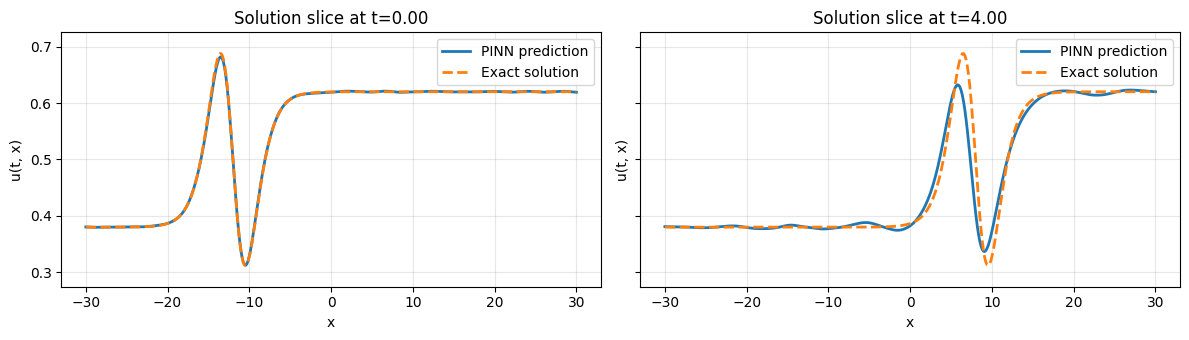

It 09050: total=3.09807441e-05, phi_r=2.89484306e-05, phi_b=4.41903429e-07, phi_0=1.59041007e-06
It 09100: total=3.80497864e-05, phi_r=3.07725747e-05, phi_b=2.53731825e-06, phi_0=4.73989343e-06
It 09150: total=2.87035218e-05, phi_r=2.68929386e-05, phi_b=4.36938087e-07, phi_0=1.37364507e-06
It 09200: total=2.75122788e-05, phi_r=2.57449363e-05, phi_b=4.17759713e-07, phi_0=1.34958276e-06
It 09250: total=1.14209566e-04, phi_r=6.33243737e-05, phi_b=1.81988770e-05, phi_0=3.26863154e-05
It 09300: total=2.57984406e-05, phi_r=2.39768638e-05, phi_b=4.82634181e-07, phi_0=1.33894264e-06
It 09350: total=2.44725706e-05, phi_r=2.29136713e-05, phi_b=3.92887161e-07, phi_0=1.16601212e-06
It 09400: total=4.18400756e-05, phi_r=2.89364756e-05, phi_b=8.98500480e-06, phi_0=3.91859521e-06
It 09450: total=2.27899521e-05, phi_r=2.13321488e-05, phi_b=3.80650998e-07, phi_0=1.07715229e-06
It 09500: total=2.19563340e-05, phi_r=2.05733519e-05, phi_b=3.68750836e-07, phi_0=1.01423128e-06
It 09550: total=2.76478004e-05

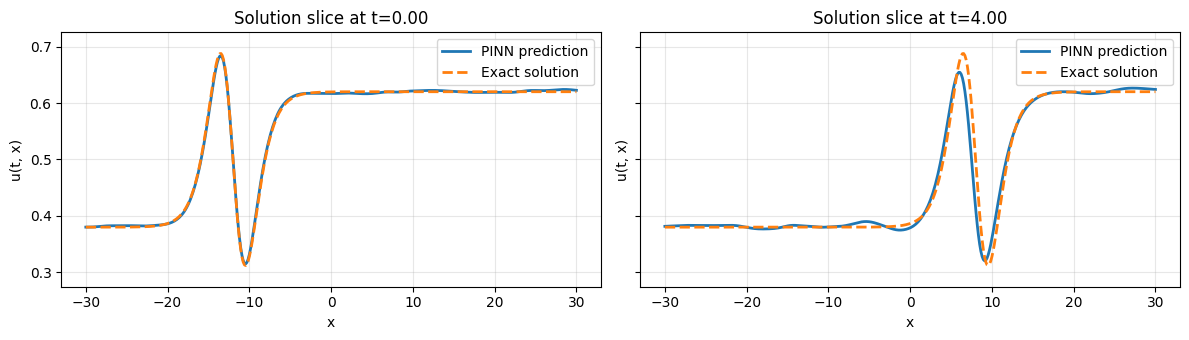

It 10050: total=1.56583649e-05, phi_r=1.45906892e-05, phi_b=3.77950526e-07, phi_0=6.89725192e-07
It 10100: total=1.49983761e-05, phi_r=1.40989722e-05, phi_b=2.92163497e-07, phi_0=6.07240384e-07
It 10150: total=1.76888747e-05, phi_r=1.44762093e-05, phi_b=1.18517311e-06, phi_0=2.02749229e-06
It 10200: total=1.41834330e-05, phi_r=1.32822663e-05, phi_b=2.84701363e-07, phi_0=6.16465394e-07
It 10250: total=1.68480045e-05, phi_r=1.32965613e-05, phi_b=1.90800063e-06, phi_0=1.64344258e-06
It 10300: total=1.34461727e-05, phi_r=1.26101634e-05, phi_b=2.62990425e-07, phi_0=5.73018871e-07
It 10350: total=1.90545954e-05, phi_r=1.46500242e-05, phi_b=1.56546614e-06, phi_0=2.83910507e-06
It 10400: total=1.27732140e-05, phi_r=1.20387874e-05, phi_b=2.46807598e-07, phi_0=4.87618947e-07
It 10450: total=1.47747239e-05, phi_r=1.28497057e-05, phi_b=6.17357440e-07, phi_0=1.30766072e-06
It 10500: total=1.23792937e-05, phi_r=1.13630442e-05, phi_b=3.10807782e-07, phi_0=7.05441744e-07
It 10550: total=1.72161837e-05

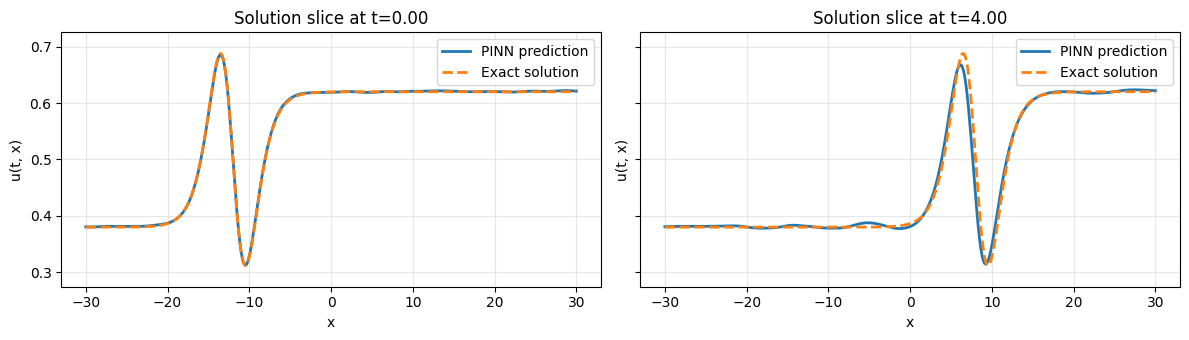

It 11050: total=9.58100316e-06, phi_r=9.00143869e-06, phi_b=2.08967169e-07, phi_0=3.70597297e-07
It 11100: total=1.64211490e-05, phi_r=1.18091924e-05, phi_b=1.24243282e-06, phi_0=3.36952377e-06
It 11150: total=9.53106182e-06, phi_r=8.84843062e-06, phi_b=2.68345794e-07, phi_0=4.14285410e-07
It 11200: total=9.61995976e-06, phi_r=8.77212318e-06, phi_b=3.64742197e-07, phi_0=4.83094381e-07
It 11250: total=8.93290799e-06, phi_r=8.42378553e-06, phi_b=2.05777401e-07, phi_0=3.03345061e-07
It 11300: total=8.75705955e-06, phi_r=8.13387407e-06, phi_b=2.04749505e-07, phi_0=4.18435975e-07
It 11350: total=1.06198193e-05, phi_r=8.84837888e-06, phi_b=1.16576937e-06, phi_0=6.05671026e-07
It 11400: total=8.35183067e-06, phi_r=7.89536068e-06, phi_b=1.63294750e-07, phi_0=2.93175238e-07
It 11450: total=3.11522184e-05, phi_r=2.18106549e-05, phi_b=6.38164985e-06, phi_0=2.95991363e-06
It 11500: total=8.09602534e-06, phi_r=7.62519322e-06, phi_b=1.63633372e-07, phi_0=3.07198746e-07
It 11550: total=1.63639902e-05

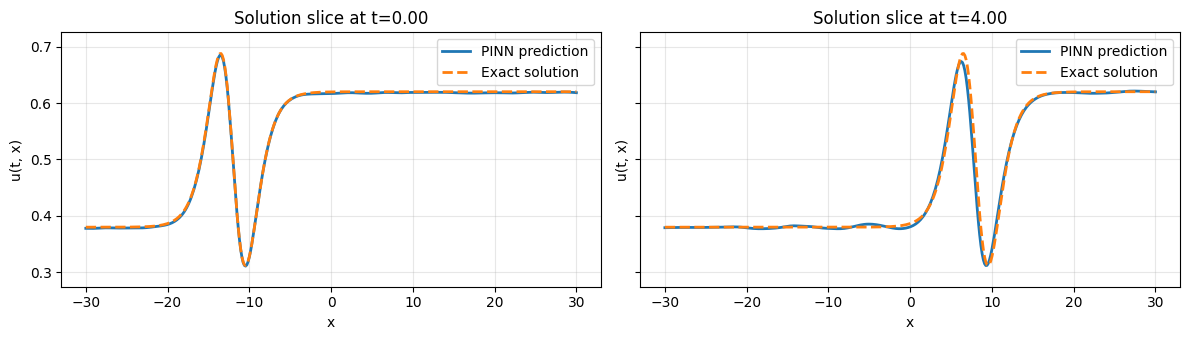

It 12050: total=6.76948901e-06, phi_r=6.40588290e-06, phi_b=1.36340329e-07, phi_0=2.27265781e-07
It 12100: total=6.64174839e-06, phi_r=6.30317177e-06, phi_b=1.25658403e-07, phi_0=2.12918217e-07
It 12150: total=1.97863531e-05, phi_r=1.45143989e-05, phi_b=3.70467727e-06, phi_0=1.56727696e-06
It 12200: total=6.58258518e-06, phi_r=6.17343803e-06, phi_b=1.42243893e-07, phi_0=2.66903261e-07
It 12250: total=8.09306682e-06, phi_r=6.76540723e-06, phi_b=4.21395605e-07, phi_0=9.06263988e-07
It 12300: total=6.30051816e-06, phi_r=5.97500668e-06, phi_b=1.24008264e-07, phi_0=2.01503211e-07
It 12350: total=1.93409402e-05, phi_r=8.71728530e-06, phi_b=7.23448690e-06, phi_0=3.38916801e-06
It 12400: total=8.51360212e-05, phi_r=3.31619501e-05, phi_b=1.74193885e-05, phi_0=3.45546826e-05
It 12450: total=6.09093139e-06, phi_r=5.70688689e-06, phi_b=1.31609728e-07, phi_0=2.52434779e-07
It 12500: total=5.52826994e-05, phi_r=3.21188720e-05, phi_b=1.28390056e-05, phi_0=1.03248218e-05
It 12550: total=5.93099054e-06

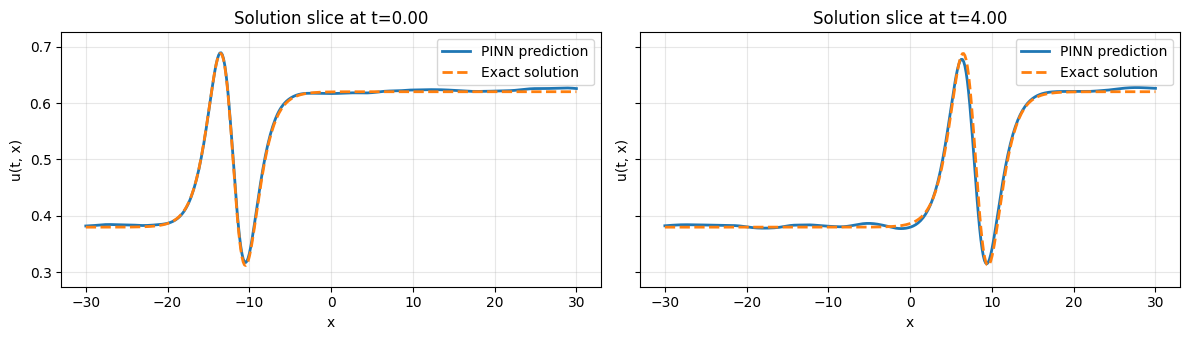


Computation time: 34792.11 seconds
History keys: ['step', 'total', 'phi_r', 'phi_b', 'phi_0', 'phi_b_u', 'phi_b_ux', 'phi_b_uxx']


In [25]:
@tf.function
def train_step():
    total_loss, phi_r, phi_b, phi_0, phi_b_u, phi_b_ux, phi_b_uxx, grad_theta = get_grad(
        model,
        X_r,
        X_data,
        u_data,
        X_lb,
        X_ub,
        w_r,
        w_0,
        lambda_r,
        lambda_b,
        lambda_0,
    )
    optim.apply_gradients(zip(grad_theta, model.trainable_variables))
    return total_loss, phi_r, phi_b, phi_0, phi_b_u, phi_b_ux, phi_b_uxx


N = 13000
history = {
    "step": [],
    "total": [],
    "phi_r": [],
    "phi_b": [],
    "phi_0": [],
    "phi_b_u": [],
    "phi_b_ux": [],
    "phi_b_uxx": [],
}

t0 = time()

for i in range(N + 1):
    total_loss, phi_r, phi_b, phi_0, phi_b_u, phi_b_ux, phi_b_uxx = train_step()

    history["step"].append(i)
    history["total"].append(float(total_loss))
    history["phi_r"].append(float(phi_r))
    history["phi_b"].append(float(phi_b))
    history["phi_0"].append(float(phi_0))
    history["phi_b_u"].append(float(phi_b_u))
    history["phi_b_ux"].append(float(phi_b_ux))
    history["phi_b_uxx"].append(float(phi_b_uxx))

    if i % 50 == 0:
        print(
            f"It {i:05d}: total={float(total_loss):.8e}, "
            f"phi_r={float(phi_r):.8e}, phi_b={float(phi_b):.8e}, phi_0={float(phi_0):.8e}"
        )

    if i % 1000 == 0:
        plot_slices((0.0, 4.0))

print(f"\nComputation time: {time() - t0:.2f} seconds")
print("History keys:", list(history.keys()))


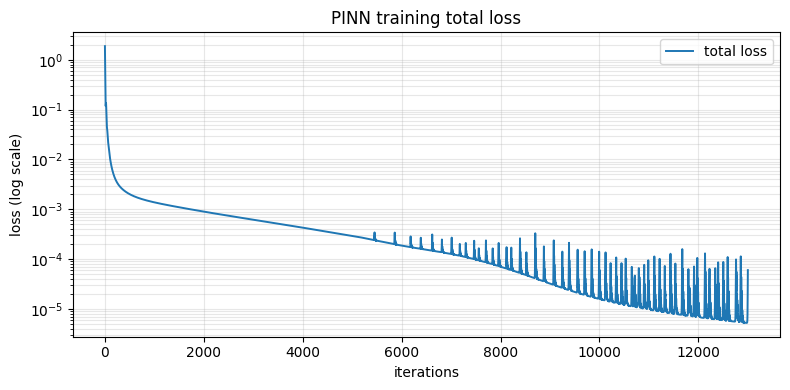

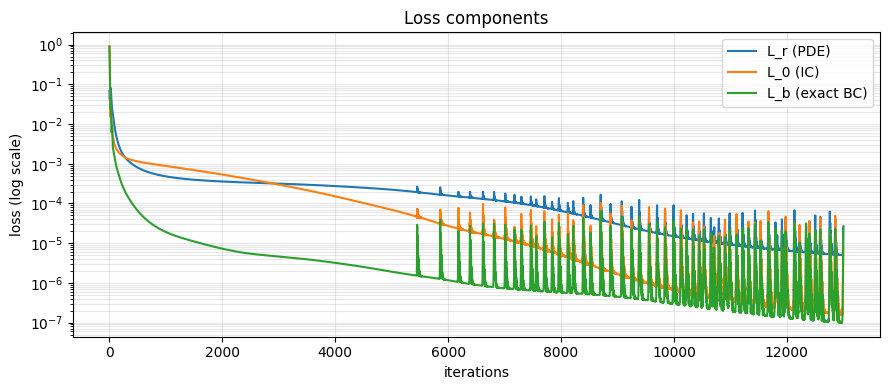

In [26]:
# Training curves: total loss in log scale + components
steps = np.array(history["step"])
total = np.array(history["total"])
eps = 1e-12

plt.figure(figsize=(8, 4))
plt.semilogy(steps, total + eps, lw=1.4, label="total loss")
plt.xlabel("iterations")
plt.ylabel("loss (log scale)")
plt.title("PINN training total loss")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 4))
plt.semilogy(steps, np.array(history["phi_r"]) + eps, label="L_r (PDE)")
plt.semilogy(steps, np.array(history["phi_0"]) + eps, label="L_0 (IC)")
plt.semilogy(steps, np.array(history["phi_b"]) + eps, label="L_b (exact BC)")
plt.xlabel("iterations")
plt.ylabel("loss (log scale)")
plt.title("Loss components")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


Top jumps (step, relative_change):
step=11680, rel_change=1.758169e+00
step=12598, rel_change=1.697666e+00
step=12864, rel_change=1.392634e+00
step=11984, rel_change=1.299582e+00
step=12509, rel_change=1.282988e+00
step=12147, rel_change=1.166971e+00
step=9081, rel_change=1.097332e+00
step=8706, rel_change=1.086709e+00
step=12140, rel_change=1.053023e+00
step=11687, rel_change=9.983276e-01

Summary:
mean rel jump: 3.368171e-02
median rel jump: 5.706011e-04
95th percentile: 2.274858e-01


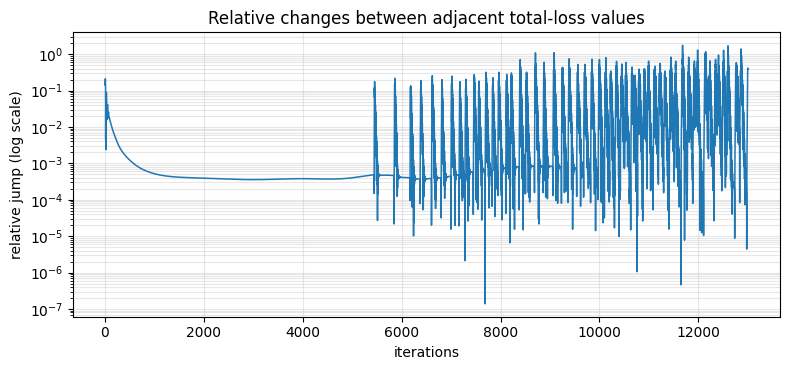

In [27]:
# Smoothness diagnostics: relative jumps |L[i]-L[i-1]| / L[i-1]
steps = np.array(history["step"])
loss_vals = np.array(history["total"])
eps = 1e-12

rel_jump = np.abs(np.diff(loss_vals)) / (np.abs(loss_vals[:-1]) + eps)
jump_steps = steps[1:]

top_k = 10 if rel_jump.size >= 10 else rel_jump.size
top_idx = np.argsort(rel_jump)[-top_k:][::-1]

print("Top jumps (step, relative_change):")
for idx in top_idx:
    print(f"step={int(jump_steps[idx])}, rel_change={rel_jump[idx]:.6e}")

print("\nSummary:")
print(f"mean rel jump: {rel_jump.mean():.6e}")
print(f"median rel jump: {np.median(rel_jump):.6e}")
print(f"95th percentile: {np.percentile(rel_jump, 95):.6e}")

plt.figure(figsize=(8, 3.8))
plt.semilogy(jump_steps, rel_jump + eps, lw=1.1)
plt.xlabel("iterations")
plt.ylabel("relative jump (log scale)")
plt.title("Relative changes between adjacent total-loss values")
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()


In [28]:
# Save final kernels, biases, and CSV export after the last stage
from pathlib import Path

final_weight_matrices = {}
final_parameters = {}

for idx, layer in enumerate(model.hidden_layers, start=1):
    kernel, bias = layer.get_weights()
    final_weight_matrices[f"hidden_{idx}_kernel"] = kernel
    final_parameters[f"hidden_{idx}_kernel"] = kernel
    final_parameters[f"hidden_{idx}_bias"] = bias

output_kernel, output_bias = model.output_layer.get_weights()
final_weight_matrices["output_kernel"] = output_kernel
final_parameters["output_kernel"] = output_kernel
final_parameters["output_bias"] = output_bias

weights_path = "start_final_weight_matrices.npz"
parameters_path = "start_final_parameters.npz"
csv_dir = Path("start_final_parameters_csv")
csv_dir.mkdir(exist_ok=True)

np.savez(weights_path, **final_weight_matrices)
np.savez(parameters_path, **final_parameters)

for name, value in final_parameters.items():
    csv_value = value if value.ndim > 1 else value.reshape(1, -1)
    np.savetxt(csv_dir / f"{name}.csv", csv_value, delimiter=",", fmt="%.18e")

print(f"Saved final weight matrices to {weights_path}")
print(f"Saved all final parameters to {parameters_path}")
print(f"Saved parameter CSV files to {csv_dir.resolve()}")
for name, value in final_parameters.items():
    print(f"{name}: shape={value.shape}")


Saved final weight matrices to start_final_weight_matrices.npz
Saved all final parameters to start_final_parameters.npz
Saved parameter CSV files to C:\Study\6-semester\start_final_parameters_csv
hidden_1_kernel: shape=(64, 64)
hidden_1_bias: shape=(64,)
hidden_2_kernel: shape=(64, 64)
hidden_2_bias: shape=(64,)
hidden_3_kernel: shape=(64, 64)
hidden_3_bias: shape=(64,)
hidden_4_kernel: shape=(64, 64)
hidden_4_bias: shape=(64,)
output_kernel: shape=(64, 1)
output_bias: shape=(1,)
